In [2]:
print(df.columns)

Index(['"Middleweight"', '1', '356831', 'boxer', 'Gennady Golovkin',
       'http://boxrec.com/list_bouts.php?human_id=356831&cat=boxer', '1085',
       '32', '29', '0', '0.1', '0.2', '32(29)-0-0',
       '{"w", "w", "w", "w", "w", "w"}', '2006', '33', 'orthodox', 'flag kz',
       'Kazakhstan', 'Los Angeles, California, USA'],
      dtype='str')



First Rows:
    "Middleweight"  1  356831  boxer         Gennady Golovkin  \
0  "Middleweight"  2   33535  boxer             Miguel Cotto   
1  "Middleweight"  3  316441  boxer            Peter Quillin   
2  "Middleweight"  4   14429  boxer  Sergio Gabriel Martinez   
3  "Middleweight"  5  344849  boxer                 Andy Lee   
4  "Middleweight"  6   31056  boxer           Jermain Taylor   

  http://boxrec.com/list_bouts.php?human_id=356831&cat=boxer  1085  32  29  0  \
0  http://boxrec.com/list_bouts.php?human_id=3353...           783  39  32  4   
1  http://boxrec.com/list_bouts.php?human_id=3164...           566  31  22  0   
2  http://boxrec.com/list_bouts.php?human_id=1442...           521  51  28  3   
3  http://boxrec.com/list_bouts.php?human_id=3448...           502  34  24  2   
4  http://boxrec.com/list_bouts.php?human_id=3105...           491  33  20  4   

   0.1  0.2     32(29)-0-0  {"w", "w", "w", "w", "w", "w"}  2006    33  \
0    2    0  39(32)-4(2)-0  {"w", "w", "

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_34078/941199561.py:107: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


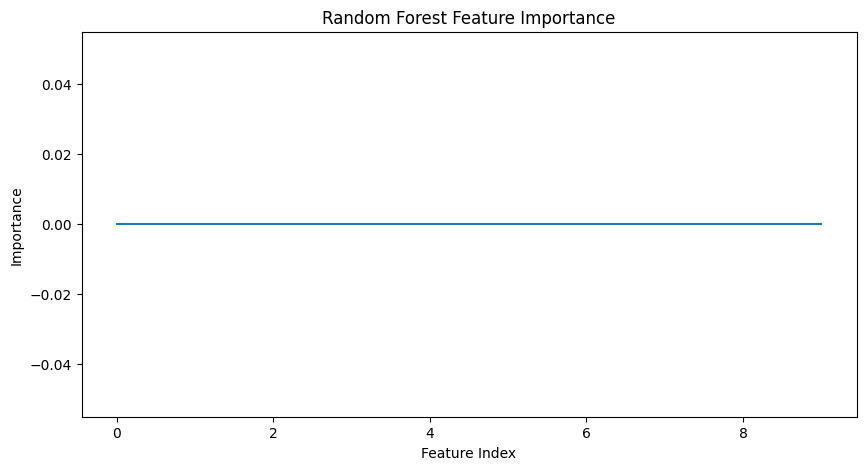

In [6]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import re

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Sparse matrix
from scipy.sparse import hstack
import scipy.sparse as sp

import matplotlib.pyplot as plt

# Download NLP resources (runs only if not installed)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_csv("boxers_Middleweight.csv")

print("\nFirst Rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

print("\nColumns:")
print(df.columns)


# ===============================
# 3. NLP Preprocessing
# ===============================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    if pd.isnull(text):
        return ""

    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    tokens = text.split()

    tokens = [w for w in tokens if w not in stop_words]

    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)


# ===============================
# 4. Detect Text Column
# ===============================
possible_text_cols = ["description","bio","style","notes","summary"]

text_column = None

for col in possible_text_cols:
    if col in df.columns:
        text_column = col
        break

print("\nDetected text column:", text_column)


# ===============================
# 5. TF-IDF Features
# ===============================
text_features = None

if text_column:

    df["clean_text"] = df[text_column].astype(str).apply(preprocess_text)

    tfidf = TfidfVectorizer(max_features=200)

    text_features = tfidf.fit_transform(df["clean_text"])


# ===============================
# 6. Numeric Features
# ===============================
numeric_features = df.select_dtypes(include=[np.number]).fillna(0)

print("\nNumeric columns used:")
print(numeric_features.columns)


# ===============================
# 7. Detect Target Column
# ===============================
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

if text_column in categorical_cols:
    categorical_cols.remove(text_column)

if len(categorical_cols) == 0:
    raise ValueError("No categorical column available to use as target.")

target_column = categorical_cols[0]

print("\nUsing target column:", target_column)

y = df[target_column]


# ===============================
# 8. Combine Features
# ===============================
if text_features is not None:

    X = hstack([text_features, sp.csr_matrix(numeric_features)])

else:

    X = numeric_features


# ===============================
# 9. Train/Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===============================
# 10. Train Random Forest
# ===============================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)


# ===============================
# 11. Evaluate Model
# ===============================
predictions = rf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))


# ===============================
# 12. Feature Importance
# ===============================
importances = rf.feature_importances_

plt.figure(figsize=(10,5))
plt.title("Random Forest Feature Importance")
plt.plot(importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()